In [4]:
import numpy as np
import pandas as pd
import os
import glob
import sys

# Must be set BEFORE importing tensorflow
os.environ["TF_NUM_INTRAOP_THREADS"] = "0"
os.environ["TF_NUM_INTEROP_THREADS"] = "0"

import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from keras.models import load_model
from keras.preprocessing import image
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [5]:
print(os.cpu_count())

12


In [6]:
CFG = {
    "train_dir": "data/real-vs-fake/train",
    "test_dir":  "data/real-vs-fake/test",
    "img_size":  (160, 160),
    "batch_size": 64,
    "epochs":    15,
    "seed":      42,
}

In [7]:
for split in ["train", "test"]:
    split_dir = os.path.join("data/real-vs-fake", split)
    for cls in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            count = len(glob.glob(os.path.join(cls_path, "*.jpg")))
            print(f"  [{split}] {cls}: {count} images")

CLASS_NAMES = ["fake", "real"] 

  [train] fake: 19233 images
  [train] real: 18307 images
  [test] fake: 10000 images
  [test] real: 10000 images


In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    CFG["train_dir"],
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=CFG["img_size"],
    batch_size=CFG["batch_size"],
    shuffle=True,
    seed=CFG["seed"],
    validation_split=0.2,
    subset="training",
)

Found 37540 files belonging to 2 classes.
Using 30032 files for training.


In [5]:
# import shutil

# # Remove any .ipynb_checkpoints folders inside the data directory
# for root, dirs, files in os.walk("data"):
#     for d in dirs:
#         if d == ".ipynb_checkpoints":
#             path = os.path.join(root, d)
#             shutil.rmtree(path)
#             print(f"Deleted: {path}")

# print("Done — re-run the dataset cells now.")

In [9]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    CFG["train_dir"],
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=CFG["img_size"],
    batch_size=CFG["batch_size"],
    shuffle=False,
    seed=CFG["seed"],
    validation_split=0.2,
    subset="validation",
)


Found 37540 files belonging to 2 classes.
Using 7508 files for validation.


In [10]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    CFG["test_dir"],
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=CFG["img_size"],
    batch_size=CFG["batch_size"],
    shuffle=False,
)
print(f"\nClasses: {CLASS_NAMES}")

Found 20000 files belonging to 2 classes.

Classes: ['fake', 'real']


In [11]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

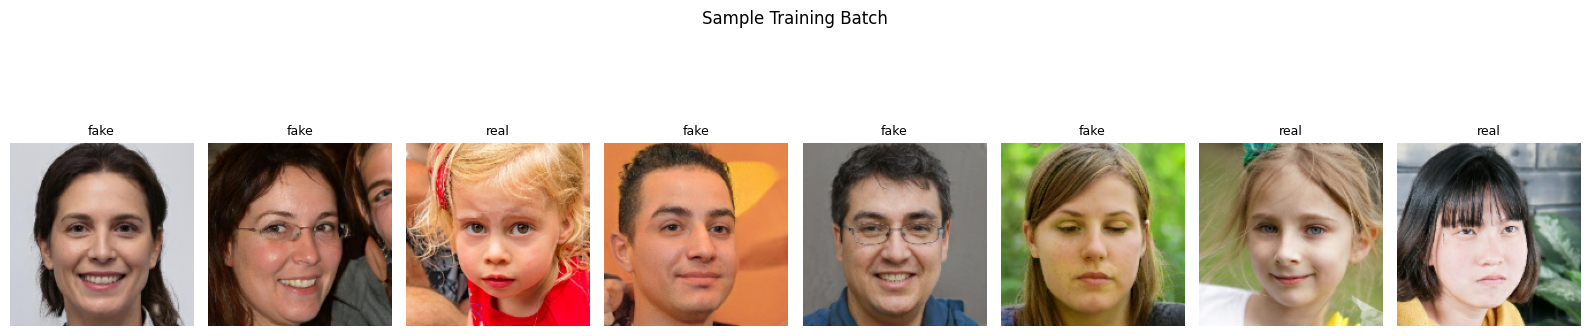

In [12]:
plt.figure(figsize=(16, 4))
for imgs, labels in train_ds.take(1):
    for i in range(8):
        plt.subplot(1, 8, i+1)
        plt.imshow(imgs[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(labels[i])], fontsize=9)
        plt.axis("off")
plt.suptitle("Sample Training Batch", y=1.02)
plt.tight_layout()
plt.show()

In [13]:
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
], name="augmentation")


preprocess_input = tf.keras.applications.resnet50.preprocess_input

In [14]:
def build_model():
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(*CFG["img_size"], 3),
    )
    base.trainable = False          # freeze backbone to start

    inputs = layers.Input(shape=(*CFG["img_size"], 3))
    x = augment(inputs)             # augmentation only active during training
    x = preprocess_input(x)         # ResNet-specific normalisation
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)  # binary output

    return tf.keras.Model(inputs, outputs)

model = build_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 160, 160, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ augmentation (Sequential)     │ (None, 160, 160, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 160, 160)          │               0 │ augmentation[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_1 (GetItem)          │ (None, 160, 160)          │               0 │ augmentation[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_2 (GetItem)          │ (None, 160, 160)          │               0 │ augmentation[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stack (Stack)                 │ (None, 160, 160, 3)       │               0 │ get_item[0][0],            │
│                               │                           │                 │ get_item_1[0][0],          │
│                               │                           │                 │ get_item_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 160, 160, 3)       │               0 │ stack[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resnet50 (Functional)         │ (None, 5, 5, 2048)        │      23,587,712 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d      │ (None, 2048)              │               0 │ resnet50[0][0]             │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 2048)              │               0 │ global_average_pooling2d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 256)               │         524,544 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 256)               │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 1)                 │             257 │ dropout_1[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
# Fix AUC bug - change label_mode to int then use standard AUC
model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc", curve="ROC", from_logits=False),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

# Update callbacks to monitor val_loss instead of val_auc
callbacks = [stardew valley
    EarlyStopping(monitor="val_loss", patience=4, mode="min", restore_best_weights=True),
    ModelCheckpoint("best_model.keras", monitor="val_loss", mode="min", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.CSVLogger("training_log.csv", append=True),
]

model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=0,
    epochs=CFG["epochs"],
    callbacks=callbacks,
)

Epoch 1/15
470/470 ━━━━━━━━━━━━━━━━━━━━ 860s 2s/step - accuracy: 0.6944 - auc: 0.7616 - loss: 0.5866 - precision: 0.6923 - recall: 0.6731 - val_accuracy: 0.6484 - val_auc: 0.0000e+00 - val_loss: 0.6095 - val_precision: 1.0000 - val_recall: 0.6484 - learning_rate: 0.0010
Epoch 2/15
470/470 ━━━━━━━━━━━━━━━━━━━━ 824s 2s/step - accuracy: 0.7349 - auc: 0.8104 - loss: 0.5305 - precision: 0.7351 - recall: 0.7145 - val_accuracy: 0.8029 - val_auc: 0.0000e+00 - val_loss: 0.4093 - val_precision: 1.0000 - val_recall: 0.8029 - learning_rate: 0.0010
Epoch 3/15
470/470 ━━━━━━━━━━━━━━━━━━━━ 880s 2s/step - accuracy: 0.7506 - auc: 0.8269 - loss: 0.5120 - precision: 0.7484 - recall: 0.7369 - val_accuracy: 0.7433 - val_auc: 0.0000e+00 - val_loss: 0.4930 - val_precision: 1.0000 - val_recall: 0.7433 - learning_rate: 0.0010
Epoch 4/15
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7542 - auc: 0.8345 - loss: 0.5012 - precision: 0.7570 - recall: 0.7279
Epoch 4: ReduceLROnPlateau reducing learning rate t

## Saving Progress

In [15]:
model.save("best_model.keras")
print("Weights saved!")

Weights saved!


In [16]:
import os
print(os.path.exists("best_model.keras"))  # should print True
print(os.path.getsize("best_model.keras"), "bytes")

True
101334012 bytes


In [23]:
# ============================================================
# Resume Training from Checkpoint
# ============================================================

import pandas as pd

# %% [1] Load the saved model
model = load_model("best_model.keras")
print("Model loaded successfully")

# %% [2] Check how many epochs have already been completed
log_path = "training_log.csv"

if os.path.exists(log_path):
    log = pd.read_csv(log_path)
    completed_epochs = len(log)
    print(f"Epochs already completed: {completed_epochs}")
    print(log[["epoch", "accuracy", "val_accuracy", "loss", "val_loss"]].to_string(index=False))
else:
    completed_epochs = 0
    print("No training log found, starting from epoch 0")

# %% [3] Resume training for remaining epochs
remaining_epochs = CFG["epochs"] - completed_epochs

if remaining_epochs <= 0:
    print("Phase 1 already complete, proceed to Phase 2 fine-tuning")
else:
    print(f"\nResuming from epoch {completed_epochs}, {remaining_epochs} epochs remaining")

    # Re-compile with same settings
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    )

    history_resumed = model.fit(
        train_ds,
        validation_data=val_ds,
        initial_epoch=completed_epochs,       # tell Keras where we left off
        epochs=CFG["epochs"],                 # total target epochs (not remaining)
        callbacks=callbacks,                  # CSVLogger has append=True so it won't overwrite
    )

Model loaded successfully
No training log found, starting from epoch 0

Resuming from epoch 0, 10 epochs remaining
Epoch 1/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 1511s 2s/step - accuracy: 0.7915 - auc: 0.8722 - loss: 0.4474 - precision: 0.7927 - recall: 0.7757 - val_accuracy: 0.8560 - val_auc: 0.0000e+00 - val_loss: 0.3197 - val_precision: 1.0000 - val_recall: 0.8560 - learning_rate: 0.0010
Epoch 2/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 1492s 2s/step - accuracy: 0.7999 - auc: 0.8804 - loss: 0.4340 - precision: 0.7992 - recall: 0.7882 - val_accuracy: 0.8881 - val_auc: 0.0000e+00 - val_loss: 0.2788 - val_precision: 1.0000 - val_recall: 0.8881 - learning_rate: 0.0010
Epoch 3/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 1506s 2s/step - accuracy: 0.8029 - auc: 0.8835 - loss: 0.4290 - precision: 0.8025 - recall: 0.7910 - val_accuracy: 0.8868 - val_auc: 0.0000e+00 - val_loss: 0.2777 - val_precision: 1.0000 - val_recall: 0.8868 - learning_rate: 0.0010
Epoch 4/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 1595s 2s/step - accuracy: 0.8